<a href="https://colab.research.google.com/github/ceuratfmg2mai/fakereviews/blob/main/02.%20categorizar_reviews_human.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción

Tras la selección de reseñas del conjunto de datos de Yelp, detallada en el [note book 1](https://github.com/ceuratfmg2mai/fakereviews/blob/main/01.%20procesamiento_datos_yelp.ipynb) abordamos el desafío de su categorización. Para ello, el subconjunto de reseñas seleccionado se distribuyó equitativamente entre el equipo de trabajo. La categorización se fundamentó en un análisis empírico de usuarios y comportamientos anómalos, con énfasis en características que la literatura señala como potencialmente indicativas de actividad sospechosa:

* Usuarios con puntuaciones extremadamente bajas y relativamente pocos votos “cool” tienden a ser considerados como generadores de reseñas falsas.
* Usuarios con puntuaciones intermedias (entre 3.09 y 4.96) y un número moderado o bajo de reseñas suelen mostrar patrones auténticos.
* Usuarios con puntuaciones excesivamente altas (> 4.96) y baja actividad o escasa interacción (pocos votos "funny", baja antigüedad, pocas reseñas) pueden ser sospechosos de actividad automatizada o fabricada



**Nota**: Los dataset están localizados en: *https://drive.google.com/drive/folders/1gNQNt4MHCHT-FiHXVTqz4vfKhgX7jfjY?usp=sharing*

# Librerías

In [52]:
import polars as pl
import pandas as pd
import pyarrow
import sys

import matplotlib.pyplot as plt
plt.style.use('Solarize_Light2')

import seaborn as sns
import time
start_time_global = time.time()
import json
import os
from google.colab import drive
from IPython.display import clear_output


color = '\033[1m\033[38;5;208m'
print(f"{color}Versión pandas: {pd.__version__}")
print(f"{color}Versión polars: {pl.__version__}")
print(f"{color}Versión pyarrow: {pyarrow.__version__}")

Versión pandas: 2.2.2
Versión polars: 1.21.0
Versión pyarrow: 18.1.0


# Inicialización y configuración de variables genéricas

# 1 - Inicialización de las variables de entorno

In [53]:
drive.mount('/content/drive', force_remount=True)
explicit_work_path = '/content/drive/MyDrive/Colab Notebooks/tfm_grupo_2/'
print(os.listdir(explicit_work_path))

Mounted at /content/drive
['yelp_academic_dataset_review_selected_0_255.jsonl', 'data_yelp', 'yelp_academic_dataset_review_selected.jsonl', 'yelp_academic_dataset_review_selected.arrow', 'yelp_academic_dataset_review_selected.csv', 'yelp_academic_dataset_review_selected_prompt.arrow', 'yelp_academic_dataset_review_selected_prompt.jsonl', 'yelp_academic_dataset_review_final_selected_1900.jsonl', 'yelp_academic_dataset_review_golden_evaluador_1.jsonl', 'yelp_academic_dataset_review_golden_evaluador_2.json', 'reviews_22052025.arrow', 'reviews_22052025.jsonl', 'reviews_22052025.csv', 'reviews_train_validation.jsonl', 'reviews_train_validation.arrow', 'reviews_train_validation.csv', 'reviews_test.jsonl', 'reviews_test.arrow', 'reviews_test.csv']


In [54]:
# Agrega la carpeta fakereviews al syspath del proyecto
if explicit_work_path not in sys.path:
    sys.path.append(explicit_work_path)
!wget https://raw.githubusercontent.com/ceuratfmg2mai/fakereviews/refs/heads/main/subconjuntos.py
from subconjuntos import SubconjuntoEquitativo, SubconjuntoEquitativoSimple

--2025-06-01 07:17:15--  https://raw.githubusercontent.com/ceuratfmg2mai/fakereviews/refs/heads/main/subconjuntos.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21531 (21K) [text/plain]
Saving to: ‘subconjuntos.py.1’

subconjuntos.py.1   100%[===================>]  21.03K  --.-KB/s    in 0.007s  

2025-06-01 07:17:17 (2.84 MB/s) - ‘subconjuntos.py.1’ saved [21531/21531]



# 2 - Lectura del fichero de las reseñas categorizadas por humanos.

En este apartado, leeremos con Polars el conjunto completo de los datos seleccionados.

In [55]:
# Lectura del fichero de las reseñas seleccionadas de yelp
review_selected_file_path = f'{explicit_work_path}reviews_22052025.jsonl'
df_data_reviews_selected_pl = pl.read_ndjson(review_selected_file_path)
print(f"\nTotal de reseñas a procesar: {df_data_reviews_selected_pl.shape[0]}")


Total de reseñas a procesar: 1950


## Visualización de la distribución
A continuación, detallamos visualmente el resultado realizado de la categorización realizada por los humanos.

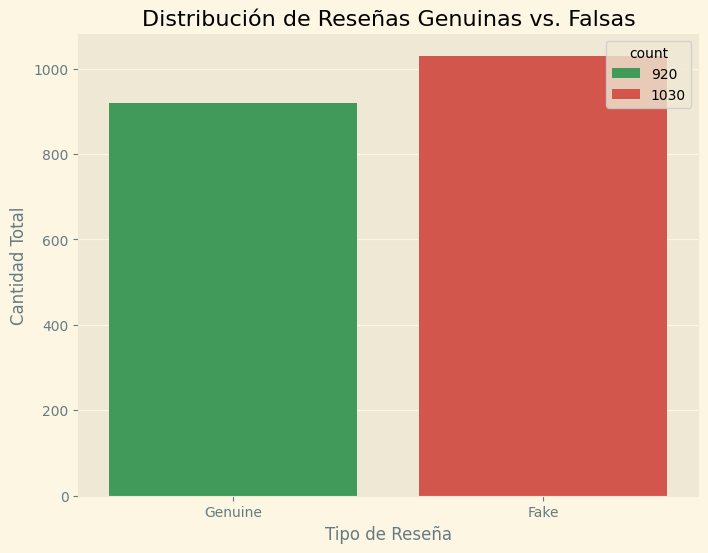

In [56]:
# Contar las ocurrencias de cada valor único en la columna 'classification'
df_counts = df_data_reviews_selected_pl['Cluster'].value_counts().to_pandas()
df_counts['Cluster'] = df_counts['Cluster'].replace({0: 'Fake', 1: 'Genuine'})
# Crear el gráfico de barras con Seaborn y Matplotlib
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Cluster', y='count', data=df_counts, palette=['#34A853', '#EA4335'], hue='count') # Genuine (verde), Fake (rojo)

# Añadir títulos y etiquetas
plt.title('Distribución de Reseñas Genuinas vs. Falsas', fontsize=16)
plt.xlabel('Tipo de Reseña', fontsize=12)
plt.ylabel('Cantidad Total', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.show()


Los conjuntos de datos preparados para el entrenamiento de modelos de aprendizaje tradicionales y de los modelos modernos o Large Language Models, exhiben un ligero pero desequilibrio entre las clases.  Hemos considerado necesario la creación de una utilidad customizada en el modulo "subconjuntos.py" para extraer de forma equilibrada cada uno de los conjuntos de datos ya que los modelos podrían desarrollar un leve sesgo hacia la clase mayoritaria.

# 3 - Separación del conjunto de datos

Para la creación de los conjuntos de entrenamiento (Training Set), validación (Validation Set) y prueba (Test Set) necesarios para nuestros modelos, procederemos de la siguiente manera con las reseñas disponibles:

0. Selección equitativa del conjunto de datos.
1. Inicialmente, se reservar reseñas que conformarán el conjunto de prueba (Test Set).
2. Las reseñas restantes, tras excluir las destinadas al conjunto de prueba, constituirán el conjunto combinado de datos para entrenamiento y validación. Este conjunto se dividirá posteriormente para crear los conjuntos de entrenamiento y validación específicos.

## Selección equitativa


In [57]:
sub_conjunto = SubconjuntoEquitativoSimple(
    df_original=df_data_reviews_selected_pl,
    columna_categoria = 'Cluster',
    semilla_aleatoria = 42
)

Se encontraron 2 categorías únicas. Ej: [1, 0]
Info: El número de categorías únicas encontradas (2) es diferente de las 32 esperadas, pero se procederá igualmente.


In [58]:
# Separamos registros para el conjunto de prueba (Train)
df_train_validation = sub_conjunto.crear_subconjunto(1750)
print("Número de registros seleccionados para Test:", df_train_validation.shape[0])
#  Separamos (Training Set) y validación (Validation Set)
df_test = df_data_reviews_selected_pl.join(
    df_train_validation.select("review_id"),
    on="review_id",
    how="anti"
)
print("Número de registros (Train/Validation):", df_train_validation.shape[0])
print("Total de registros (Test + Train/Validation):", df_test.shape[0] + df_train_validation.shape[0])
print("Total de registros original:", df_data_reviews_selected_pl.shape[0])

Registros objetivo: 1750
Registros base por categoría: 875
0 categorías aportarán 876 registros.
2 categorías aportarán 875 registros.
Número de registros seleccionados para Test: 1750
Número de registros (Train/Validation): 1750
Total de registros (Test + Train/Validation): 1950
Total de registros original: 1950


## Visualización de la selección de los registros de Test

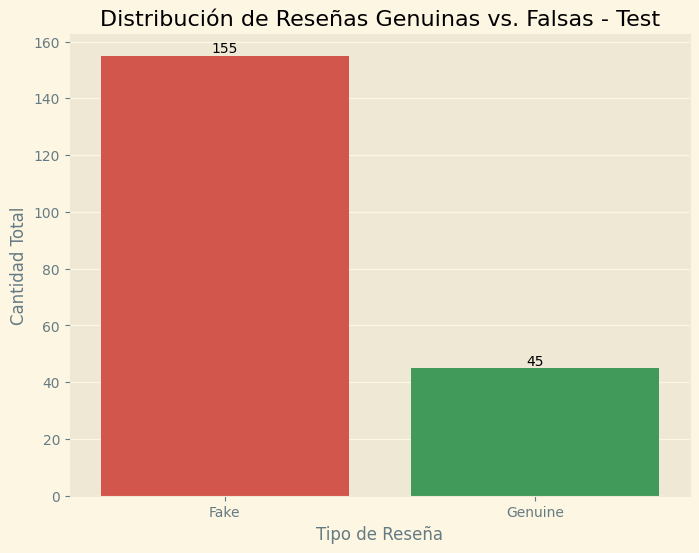

In [59]:
# Contar las ocurrencias de cada valor único en la columna 'classification'
df_counts = df_test['Cluster'].value_counts().to_pandas()
df_counts['Cluster'] = df_counts['Cluster'].replace({0: 'Fake', 1: 'Genuine'})

# Create a dictionary to map categories to colors for the palette
color_map = {'Genuine': '#34A853', 'Fake': '#EA4335'}

# Create the bar plot with Seaborn and Matplotlib
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Cluster', y='count', data=df_counts, hue='Cluster', palette=color_map)

# Add titles and labels
plt.title('Distribución de Reseñas Genuinas vs. Falsas - Test', fontsize=16)
plt.xlabel('Tipo de Reseña', fontsize=12)
plt.ylabel('Cantidad Total', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',           # Texto a mostrar (la altura de la barra como entero)
                (p.get_x() + p.get_width() / 2., p.get_height()), # Posición (x, y) para el texto
                ha='center',                       # Alineación horizontal
                va='center',                       # Alineación vertical
                xytext=(0, 5),                    # Desplazamiento del texto (en puntos): 0 horizontal, 5 vertical (encima de la barra)
                textcoords='offset points',        # Usar coordenadas de desplazamiento
                fontsize=10)                       # Tamaño de la fuente para la anotación

plt.show()

## Visualización de la selección de los registros para Train/Validation

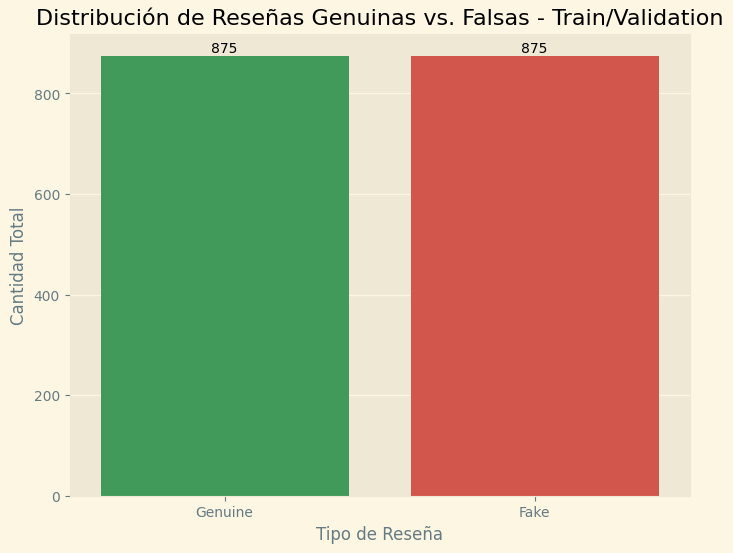

In [60]:
# Contar las ocurrencias de cada valor único en la columna 'classification'
df_counts = df_train_validation['Cluster'].value_counts().to_pandas()
df_counts['Cluster'] = df_counts['Cluster'].replace({0: 'Fake', 1: 'Genuine'})

# Create a dictionary to map categories to colors for the palette
color_map = {'Genuine': '#34A853', 'Fake': '#EA4335'}

# Create the bar plot with Seaborn and Matplotlib
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Cluster', y='count', data=df_counts, hue='Cluster', palette=color_map)

# Add titles and labels
plt.title('Distribución de Reseñas Genuinas vs. Falsas - Train/Validation', fontsize=16)
plt.xlabel('Tipo de Reseña', fontsize=12)
plt.ylabel('Cantidad Total', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',           # Texto a mostrar (la altura de la barra como entero)
                (p.get_x() + p.get_width() / 2., p.get_height()), # Posición (x, y) para el texto
                ha='center',                       # Alineación horizontal
                va='center',                       # Alineación vertical
                xytext=(0, 5),                    # Desplazamiento del texto (en puntos): 0 horizontal, 5 vertical (encima de la barra)
                textcoords='offset points',        # Usar coordenadas de desplazamiento
                fontsize=10)                       # Tamaño de la fuente para la anotación


plt.show()

# Guardar los conjuntos de datos de las reseñas seleccionadas

In [61]:
def guardar_dataframe_polars(df: pl.DataFrame, base_path: str):
  """
  Guarda un DataFrame de Polars en los formatos jsonl, arrow y csv.

  Args:
    df: El DataFrame de Polars a guardar.
    base_path: La ruta base para los archivos de salida (sin extensión).
               Por ejemplo, '/content/drive/MyDrive/Colab Notebooks/tfm_grupo_2/reviews_xx'
  """
  try:
    # Guardar como JSONL
    jsonl_path = f'{base_path}.jsonl'
    df.write_ndjson(jsonl_path)
    print(f'Fichero guardado en JSONL: {jsonl_path}')
  except Exception as e:
    print(f"Error al guardar jsonl: {e}")

  try:
    # Guardar como Arrow IPC
    arrow_path = f'{base_path}.arrow'
    df.write_ipc(arrow_path, compression='zstd')
    print(f'Fichero guardado en IPC: {arrow_path}')
  except Exception as e:
    print(f"Error al guardar IPC: {e}")

  try:
    # Guardar como CSV
    csv_path = f'{base_path}.csv'
    df.write_csv(csv_path)
    print(f'Fichero guardado en CSV: {csv_path}')
  except Exception as e:
    print(f"Error al guardar CSV: {e}")

In [62]:
guardar_dataframe_polars(df_train_validation, f'{explicit_work_path}reviews_train_validation')
guardar_dataframe_polars(df_test, f'{explicit_work_path}reviews_test')

Fichero guardado en JSONL: /content/drive/MyDrive/Colab Notebooks/tfm_grupo_2/reviews_train_validation.jsonl
Fichero guardado en IPC: /content/drive/MyDrive/Colab Notebooks/tfm_grupo_2/reviews_train_validation.arrow
Fichero guardado en CSV: /content/drive/MyDrive/Colab Notebooks/tfm_grupo_2/reviews_train_validation.csv
Fichero guardado en JSONL: /content/drive/MyDrive/Colab Notebooks/tfm_grupo_2/reviews_test.jsonl
Fichero guardado en IPC: /content/drive/MyDrive/Colab Notebooks/tfm_grupo_2/reviews_test.arrow
Fichero guardado en CSV: /content/drive/MyDrive/Colab Notebooks/tfm_grupo_2/reviews_test.csv


# Conclusión

Los conjuntos de datos destinados al entrenamiento y prueba de los modelos de IA han sido preparados y segmentados. El conjunto de entrenamiento/validación se compone de 875 reseñas "Genuinas" y 875 "Falsas". Por su parte, el conjunto de prueba presenta 45 reseñas "Genuinas" y 155 "Falsas". Esta distribución de las clases en ambos conjuntos establece el contexto con el que los modelos aprenderán a diferenciar los tipos de reseñas y sobre el cual se medirá su rendimiento final en la tarea de clasificación.



# Total ejecución del notebook

In [63]:
print(f'Total ejecución {time.time() - start_time_global:.2f} segundos')

Total ejecución 5.54 segundos
